Matched cells: 344,155 (after alignment and masking)


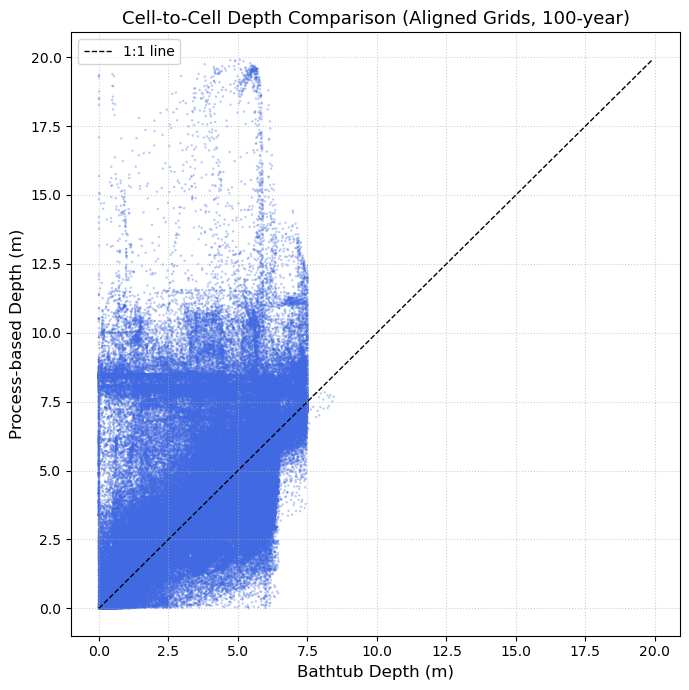

In [4]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# -------- USER INPUTS --------
r_process = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # process-based depth
r_bathtub = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"    # bathtub depth

# -------- READ PROCESS (REFERENCE GRID) --------
with rasterio.open(r_process) as sp:
    proc = sp.read(1).astype(float)
    proc_crs = sp.crs
    proc_transform = sp.transform
    proc_shape = (sp.height, sp.width)
    nodata_p = sp.nodata if sp.nodata is not None else -9999.0

# -------- READ BATHTUB --------
with rasterio.open(r_bathtub) as sb:
    bath_raw = sb.read(1).astype(float)
    bath_crs = sb.crs
    bath_transform = sb.transform
    nodata_b = sb.nodata if sb.nodata is not None else -9999.0

# -------- ALIGN BATHTUB TO PROCESS GRID IF NEEDED --------
needs_reproj = (bath_crs != proc_crs) or (bath_transform != proc_transform) or (bath_raw.shape != proc_shape)

if needs_reproj:
    # Destination array on EXACT process grid
    bath = np.full(proc_shape, nodata_b, dtype=float)
    reproject(
        source=bath_raw,
        destination=bath,
        src_transform=bath_transform,
        src_crs=bath_crs,
        dst_transform=proc_transform,
        dst_crs=proc_crs,
        src_nodata=nodata_b,
        dst_nodata=nodata_b,
        # Depth is continuous; bilinear smooths while aligning to grid.
        # If you must preserve original cell values, switch to Resampling.nearest.
        resampling=Resampling.bilinear
    )
else:
    bath = bath_raw

# -------- BUILD VALID MASK (exact cell indices on the process grid) --------
mask = np.isfinite(proc) & np.isfinite(bath)
if nodata_p is not None:
    mask &= (proc != nodata_p)
if nodata_b is not None:
    mask &= (bath != nodata_b)
# Keep only non-negative depths (comment out if not desired)
mask &= (proc >= 0) & (bath >= 0)

y = proc[mask]   # process-based depth (Y-axis)
x = bath[mask]   # bathtub depth (X-axis)
print(f"Matched cells: {x.size:,} (after alignment and masking)")

# -------- SCATTER PLOT --------
plt.figure(figsize=(7,7))
# For very large rasters, you can swap to hexbin for clarity (see comment below).
plt.scatter(x, y, s=3, alpha=0.35, edgecolor='none', color='royalblue')

# 1:1 dotted line
max_val = float(max(x.max() if x.size else 0, y.max() if y.size else 0))
plt.plot([0, max_val], [0, max_val], linestyle='--', color='k', linewidth=1, label='1:1 line')

plt.xlabel("Bathtub Depth (m)", fontsize=12)
plt.ylabel("Process-based Depth (m)", fontsize=12)
plt.title("Cell-to-Cell Depth Comparison (Aligned Grids, 100-year)", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# If the scatter is too dense, replace the scatter with this for a clearer density view:
# plt.figure(figsize=(7,7))
# hb = plt.hexbin(x, y, gridsize=200, bins='log')
# plt.plot([0, max_val], [0, max_val], '--k', linewidth=1)
# plt.xlabel("Bathtub Depth (m)"); plt.ylabel("Process-based Depth (m)")
# plt.title("Cell-to-Cell Depth Comparison (Hexbin Density)")
# plt.colorbar(hb, label='log10(count)')
# plt.tight_layout(); plt.show()


Matched valid cells (depth ≤ 8 m): 320,164


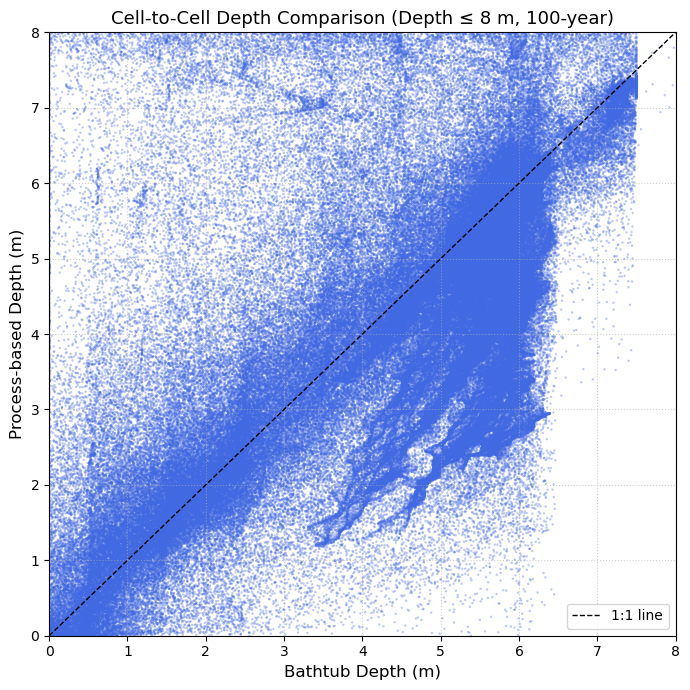

In [8]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# -------- USER INPUTS --------
r_process = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # process-based depth
r_bathtub = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"    # bathtub depth

# -------- READ PROCESS (REFERENCE GRID) --------
with rasterio.open(r_process) as sp:
    proc = sp.read(1).astype(float)
    proc_crs = sp.crs
    proc_transform = sp.transform
    proc_shape = (sp.height, sp.width)
    nodata_p = sp.nodata if sp.nodata is not None else -9999.0

# -------- READ BATHTUB --------
with rasterio.open(r_bathtub) as sb:
    bath_raw = sb.read(1).astype(float)
    bath_crs = sb.crs
    bath_transform = sb.transform
    nodata_b = sb.nodata if sb.nodata is not None else -9999.0

# -------- ALIGN BATHTUB TO PROCESS GRID IF NEEDED --------
needs_reproj = (bath_crs != proc_crs) or (bath_transform != proc_transform) or (bath_raw.shape != proc_shape)

if needs_reproj:
    bath = np.full(proc_shape, nodata_b, dtype=float)
    reproject(
        source=bath_raw,
        destination=bath,
        src_transform=bath_transform,
        src_crs=bath_crs,
        dst_transform=proc_transform,
        dst_crs=proc_crs,
        src_nodata=nodata_b,
        dst_nodata=nodata_b,
        resampling=Resampling.bilinear
    )
else:
    bath = bath_raw

# -------- BUILD VALID MASK (cell-to-cell) --------
mask = (
    np.isfinite(proc) & np.isfinite(bath) &
    (proc != nodata_p) & (bath != nodata_b) &
    (proc >= 0) & (bath >= 0) &
    (proc <= 8) & (bath <= 8)     # <-- skip values greater than 12 m
)

y = proc[mask]
x = bath[mask]
print(f"Matched valid cells (depth ≤ 8 m): {x.size:,}")

# -------- SCATTER PLOT --------
plt.figure(figsize=(7,7))
plt.scatter(x, y, s=3, alpha=0.35, edgecolor='none', color='royalblue')

# 1:1 dotted line
max_val = 8
plt.plot([0, max_val], [0, max_val], linestyle='--', color='k', linewidth=1, label='1:1 line')

plt.xlabel("Bathtub Depth (m)", fontsize=12)
plt.ylabel("Process-based Depth (m)", fontsize=12)
plt.title("Cell-to-Cell Depth Comparison (Depth ≤ 8 m, 100-year)", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()
